          ds      y day_of_week    month  is_festival  is_market_drop  \
0 2023-01-01  35789      Sunday  January            0               0   
1 2023-01-02  43764      Monday  January            0               0   
2 2023-01-03  58804     Tuesday  January            0               0   
3 2023-01-04  60401   Wednesday  January            0               0   
4 2023-01-05  14456    Thursday  January            0               1   

   gst_filing_flag  month_num  dow_num  
0                0          1        6  
1                0          1        0  
2                0          1        1  
3                0          1        2  
4                0          1        3  

                         ds              y  is_festival  is_market_drop  \
count                  731     731.000000   731.000000      731.000000   
mean   2024-01-01 00:00:00   55130.134063     0.172367        0.123119   
min    2023-01-01 00:00:00   12521.000000     0.000000        0.000000   
25%    2023-07-02

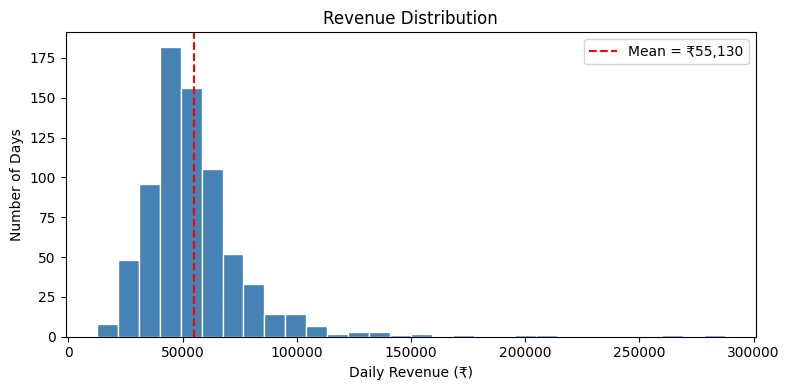

Saved plot01_histogram.png


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("msme_cashflow_2yr.csv", parse_dates=["ds"])
df = df.sort_values("ds").reset_index(drop=True)

# Add basic columns
df["month_num"] = df["ds"].dt.month
df["dow_num"]   = df["ds"].dt.dayofweek   # 0=Mon, 6=Sun

print(df.head())
print("\n", df.describe())
print("\n", df.info())


# ── CELL 1: Revenue Distribution (Histogram) ─────────────
plt.figure(figsize=(8, 4))
plt.hist(df["y"], bins=30, color="steelblue", edgecolor="white")
plt.axvline(df["y"].mean(), color="red", linestyle="--", label=f"Mean = ₹{df['y'].mean():,.0f}")
plt.xlabel("Daily Revenue (₹)")
plt.ylabel("Number of Days")
plt.title("Revenue Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("plot01_histogram.png")
plt.show()
print("Saved plot01_histogram.png")

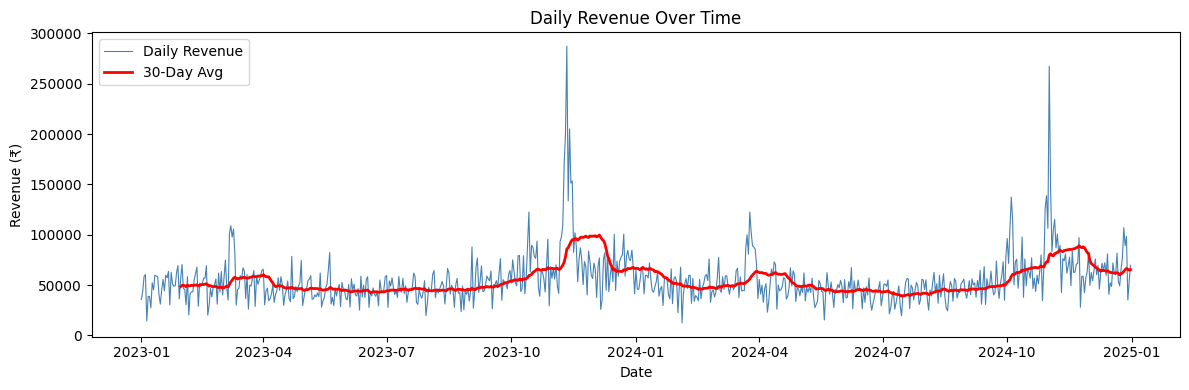

Saved plot02_timeseries.png


In [22]:
# CELL 2: Revenue Over Time (Line Plot) ────────────────
plt.figure(figsize=(12, 4))
plt.plot(df["ds"], df["y"], color="steelblue", linewidth=0.8, label="Daily Revenue")
plt.plot(df["ds"], df["y"].rolling(30).mean(), color="red", linewidth=2, label="30-Day Avg")
plt.xlabel("Date")
plt.ylabel("Revenue (₹)")
plt.title("Daily Revenue Over Time")
plt.legend()
plt.tight_layout()
plt.savefig("plot02_timeseries.png")
plt.show()
print("Saved plot02_timeseries.png")

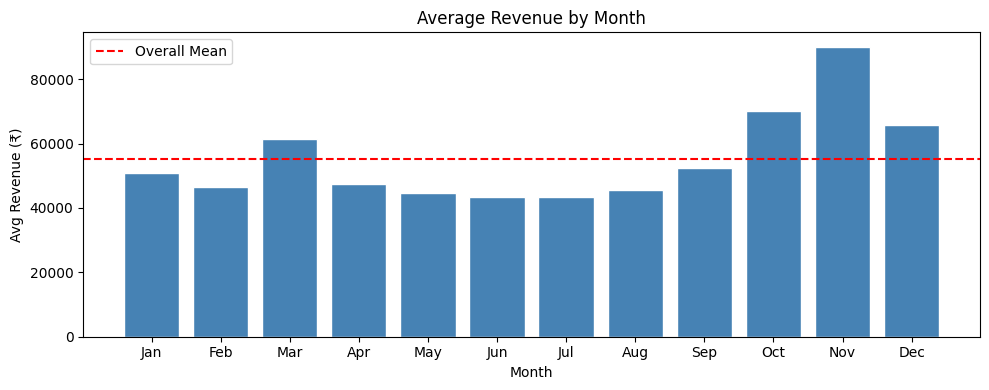

Saved plot03_monthly.png


In [23]:
# ── CELL 3: Average Revenue by Month (Bar Chart) ─────────
df["month"] = df["ds"].dt.month_name()  # creates "January", "February" etc.

month_order = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
month_avg = df.groupby("month")["y"].mean().reindex(month_order)

plt.figure(figsize=(10, 4))
plt.bar(range(12), month_avg.values, color="steelblue", edgecolor="white")
plt.xticks(range(12), ["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.axhline(df["y"].mean(), color="red", linestyle="--", label="Overall Mean")
plt.xlabel("Month")
plt.ylabel("Avg Revenue (₹)")
plt.title("Average Revenue by Month")
plt.legend()
plt.tight_layout()
plt.savefig("plot03_monthly.png")
plt.show()
print("Saved plot03_monthly.png")

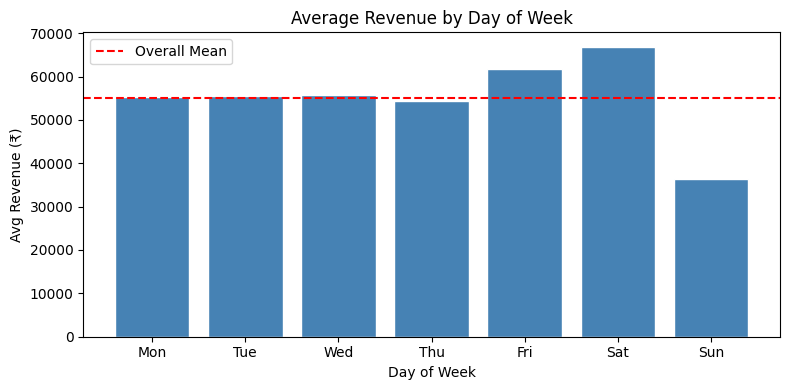

Saved plot04_dayofweek.png


In [24]:
# ── CELL 4: Average Revenue by Day of Week (Bar Chart) ───
df["day_of_week"] = df["ds"].dt.day_name()  # creates "Monday", "Tuesday" etc.

dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_avg   = df.groupby("day_of_week")["y"].mean().reindex(dow_order)

plt.figure(figsize=(8, 4))
plt.bar(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"],
        dow_avg.values, color="steelblue", edgecolor="white")
plt.axhline(df["y"].mean(), color="red", linestyle="--", label="Overall Mean")
plt.xlabel("Day of Week")
plt.ylabel("Avg Revenue (₹)")
plt.title("Average Revenue by Day of Week")
plt.legend()
plt.tight_layout()
plt.savefig("plot04_dayofweek.png")
plt.show()
print("Saved plot04_dayofweek.png")

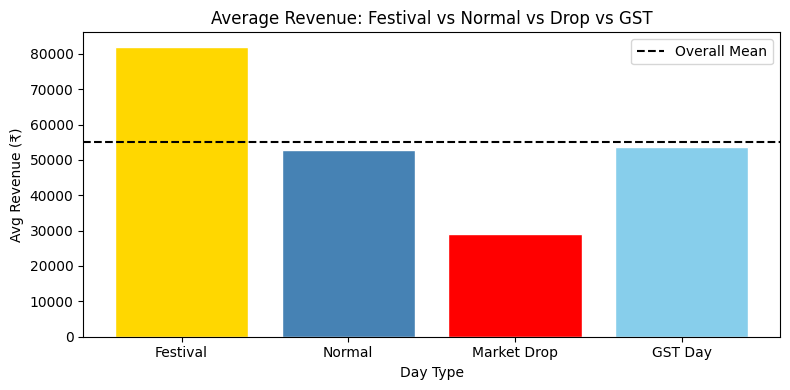

Saved plot05_daytypes.png


In [25]:

# ── CELL 5: Festival vs Normal vs Drop Days (Bar Chart) ──
type_avg = {
    "Festival":    df[df["is_festival"]    == 1]["y"].mean(),
    "Normal":      df[(df["is_festival"]==0) & (df["is_market_drop"]==0)]["y"].mean(),
    "Market Drop": df[df["is_market_drop"] == 1]["y"].mean(),
    "GST Day":     df[df["gst_filing_flag"]== 1]["y"].mean(),
}

plt.figure(figsize=(8, 4))
plt.bar(type_avg.keys(), type_avg.values(),
        color=["gold","steelblue","red","skyblue"], edgecolor="white")
plt.axhline(df["y"].mean(), color="black", linestyle="--", label="Overall Mean")
plt.xlabel("Day Type")
plt.ylabel("Avg Revenue (₹)")
plt.title("Average Revenue: Festival vs Normal vs Drop vs GST")
plt.legend()
plt.tight_layout()
plt.savefig("plot05_daytypes.png")
plt.show()
print("Saved plot05_daytypes.png")

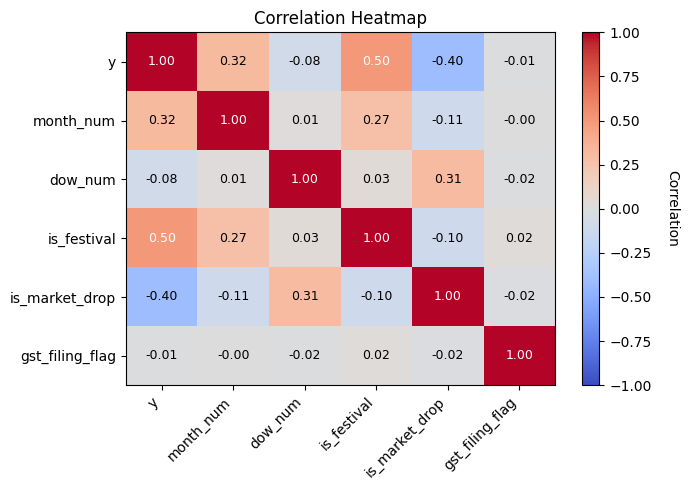

Saved plot06_correlation.png

 All 6 plots saved. No seaborn needed!


In [26]:
# ── CELL 6: Correlation Heatmap (Pure Matplotlib) ────────
num_cols = ["y", "month_num", "dow_num",
            "is_festival", "is_market_drop", "gst_filing_flag"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation", rotation=270, labelpad=20)

# Set ticks and labels
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=45, ha="right")
ax.set_yticklabels(num_cols)

# Add correlation values as text
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        val = corr.iloc[i, j]
        text_color = "white" if abs(val) > 0.5 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                color=text_color, fontsize=9)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plot06_correlation.png")
plt.show()
print("Saved plot06_correlation.png")

print("\n All 6 plots saved. No seaborn needed!")